# Project 2 — Exploratory Data Analysis (EDA)
### DecodeLabs | Data Analytics Internship — Batch 2026

**Analyst:** Intern, DecodeLabs Data Analytics Track
**Dataset:** `ecommerce_orders_cleaned.csv` (verified output of Project 1 — Data Cleaning & Preparation)
**Objective:** Interrogate the cleaned transactional dataset to uncover
patterns, trends, and outliers — transforming a static table of numbers into
meaningful, decision-ready business insights.

This notebook follows the **IPO framework** defined in the project brief:

| Stage | What it means here |
|---|---|
| **Input** | The verified evidence — `ecommerce_orders_cleaned.csv` (1,200 orders) |
| **Process** | Descriptive statistics, distribution analysis, outlier detection, correlation mapping |
| **Output** | Actionable insights, an executive summary, and visual evidence for stakeholders |

Every finding below is run through the **"So What?" test**: a statistic is
only reported if it is translated into a business-relevant statement.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

DATA_PATH = Path('../data/ecommerce_orders_cleaned.csv')
VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

print("Environment ready.")


Environment ready.


## 2. Load the Cleaned Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 1,200 | Columns: 14


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,Save10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,Save10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,Freeship,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,Save10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,Save10,Email,2504.04


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


## 3. Descriptive Statistics
Calculating the five-number summary (min, Q1, median, Q3, max) plus mean and
standard deviation for every numeric field — the "logic skeleton" of the
dataset.


In [4]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc = desc[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
desc.round(2)


,count,mean,median,std,min,25%,50%,75%,max
Quantity,1200.0,2.95,3.00,1.41,1.00,2.00,3.00,4.00,5.00
UnitPrice,1200.0,356.41,364.21,197.18,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1200.0,5.48,5.00,2.28,1.00,4.00,5.00,7.00,10.00
TotalPrice,1200.0,1053.97,823.62,819.86,11.39,410.52,823.62,1578.48,3456.40


In [5]:
mean_tp = df['TotalPrice'].mean()
median_tp = df['TotalPrice'].median()
print(f"TotalPrice -> Mean: ${mean_tp:,.2f} | Median: ${median_tp:,.2f}")
print("Mean > Median confirms a right-skewed distribution (a few high-value orders pull the average up).")


TotalPrice -> Mean: $1,053.97 | Median: $823.62
Mean > Median confirms a right-skewed distribution (a few high-value orders pull the average up).


## 4. Univariate Analysis — The Geometry of Distribution
Visualizing the shape of each key numeric variable to check for skew before
drawing conclusions from averages.


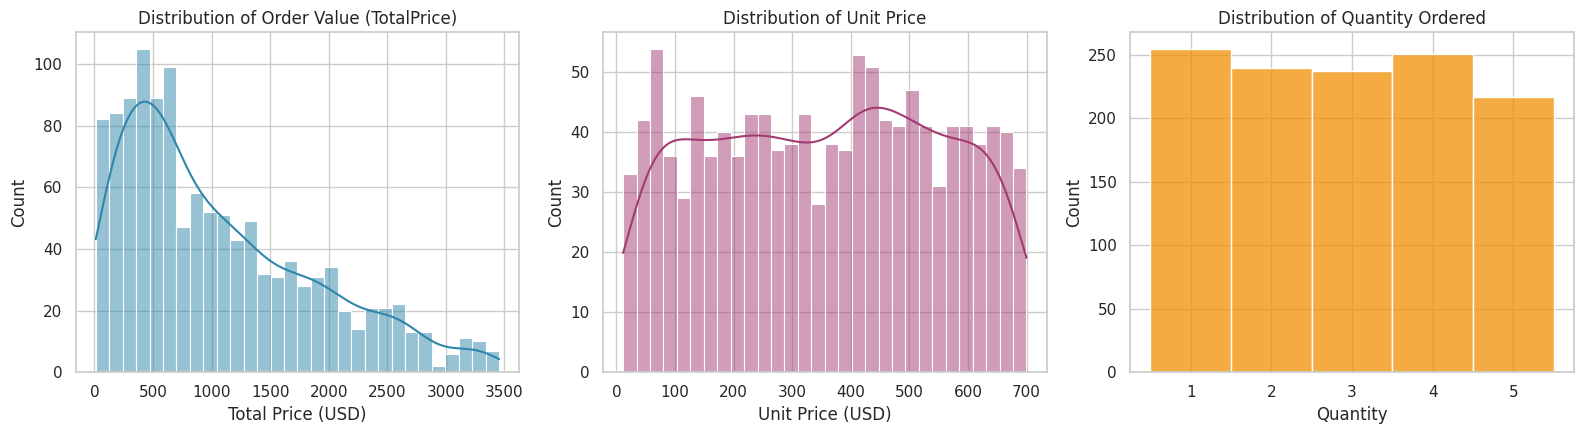

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['TotalPrice'], bins=30, kde=True, color='#2E86AB', ax=axes[0])
axes[0].set_title('Distribution of Order Value (TotalPrice)')
axes[0].set_xlabel('Total Price (USD)')

sns.histplot(df['UnitPrice'], bins=30, kde=True, color='#A23B72', ax=axes[1])
axes[1].set_title('Distribution of Unit Price')
axes[1].set_xlabel('Unit Price (USD)')

sns.histplot(df['Quantity'], bins=5, kde=False, color='#F18F01', ax=axes[2], discrete=True)
axes[2].set_title('Distribution of Quantity Ordered')
axes[2].set_xlabel('Quantity')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_univariate_distributions.png', bbox_inches='tight')
plt.show()


**Observation:** `TotalPrice` is right-skewed (a long tail of high-value orders), while `Quantity` is close to uniform across 1–5 units per order — expected for a randomized order-line dataset.

## 5. Categorical Breakdown
Counting and ranking every categorical dimension to understand the
composition of the order book.


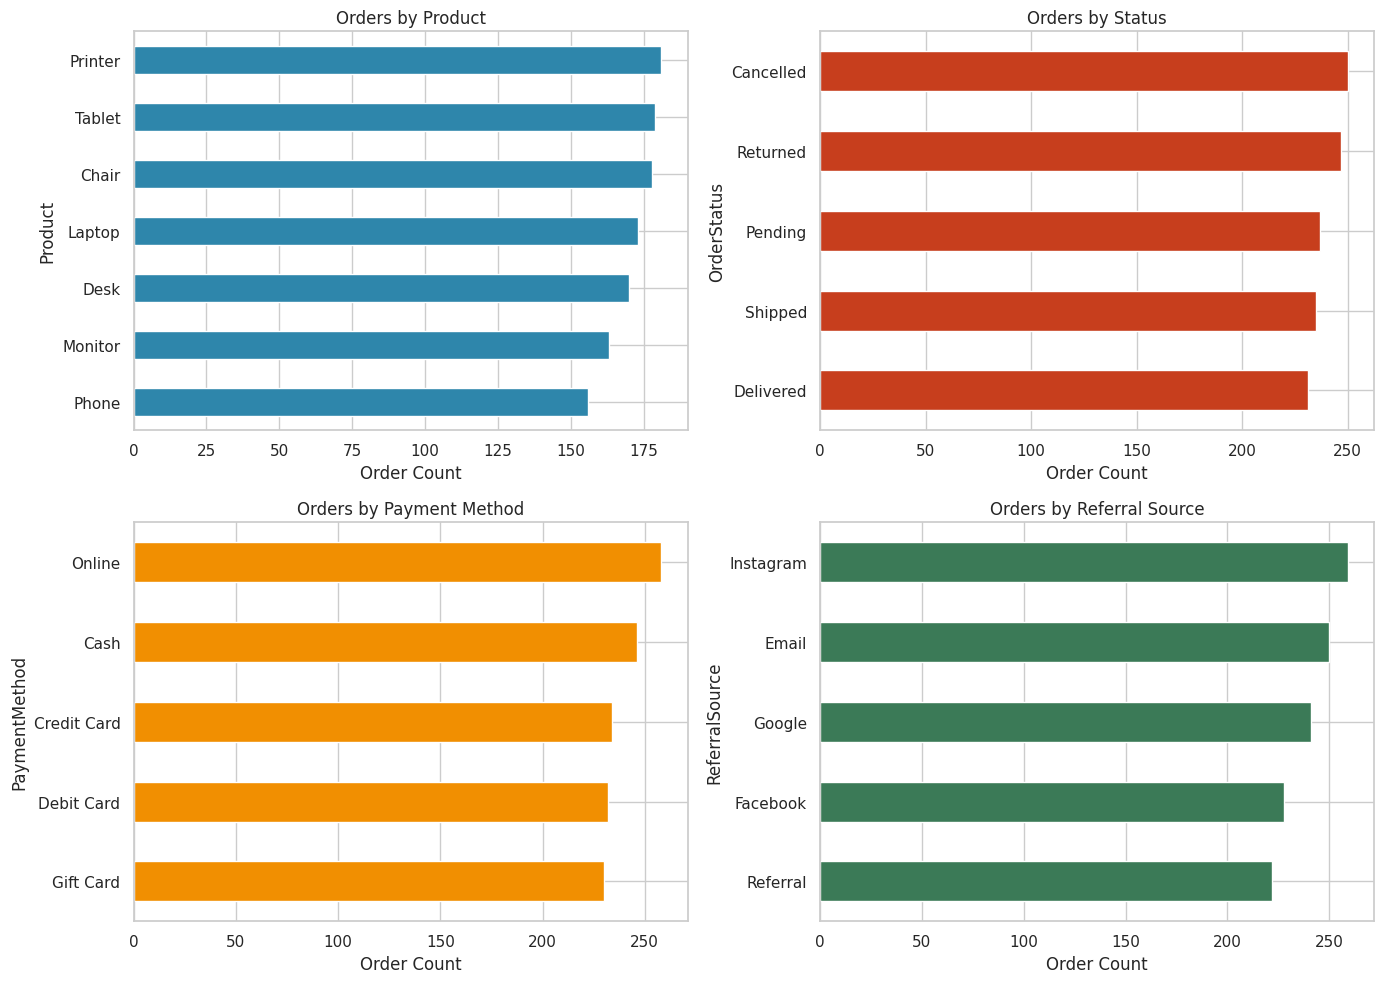

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Product'].value_counts().sort_values().plot(kind='barh', ax=axes[0,0], color='#2E86AB')
axes[0,0].set_title('Orders by Product')
axes[0,0].set_xlabel('Order Count')

df['OrderStatus'].value_counts().sort_values().plot(kind='barh', ax=axes[0,1], color='#C73E1D')
axes[0,1].set_title('Orders by Status')
axes[0,1].set_xlabel('Order Count')

df['PaymentMethod'].value_counts().sort_values().plot(kind='barh', ax=axes[1,0], color='#F18F01')
axes[1,0].set_title('Orders by Payment Method')
axes[1,0].set_xlabel('Order Count')

df['ReferralSource'].value_counts().sort_values().plot(kind='barh', ax=axes[1,1], color='#3B7A57')
axes[1,1].set_title('Orders by Referral Source')
axes[1,1].set_xlabel('Order Count')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_categorical_breakdown.png', bbox_inches='tight')
plt.show()


In [8]:
status_pct = (df['OrderStatus'].value_counts(normalize=True) * 100).round(2)
status_pct


OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: proportion, dtype: float64

**🚩 Key Finding — Order Fulfillment Risk:** `Cancelled` and `Returned`
orders together account for a large share of all orders — not a minor edge
case, but a systemic pattern worth flagging to operations/product teams
(quantified precisely in Section 8).


## 6. Outlier Detection — IQR Method
Using the IQR method (`Outlier < Q1 - 1.5×IQR` or `Outlier > Q3 + 1.5×IQR`),
which is robust against extreme values and well-suited to real-world,
non-normally-distributed business data.


In [9]:
def iqr_outlier_summary(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return {
        'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
        'outlier_count': len(outliers), 'outlier_pct': round(len(outliers) / len(series) * 100, 2)
    }

outlier_report = pd.DataFrame({
    col: iqr_outlier_summary(df[col]) for col in numeric_cols
}).T
outlier_report


,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
Quantity,2.00,4.00,2.00,-1.00,7.00,0.0,0.00
UnitPrice,186.06,521.57,335.51,-317.20,1024.83,0.0,0.00
ItemsInCart,4.00,7.00,3.00,-0.50,11.50,0.0,0.00
TotalPrice,410.52,1578.48,1167.96,-1341.41,3330.41,8.0,0.67


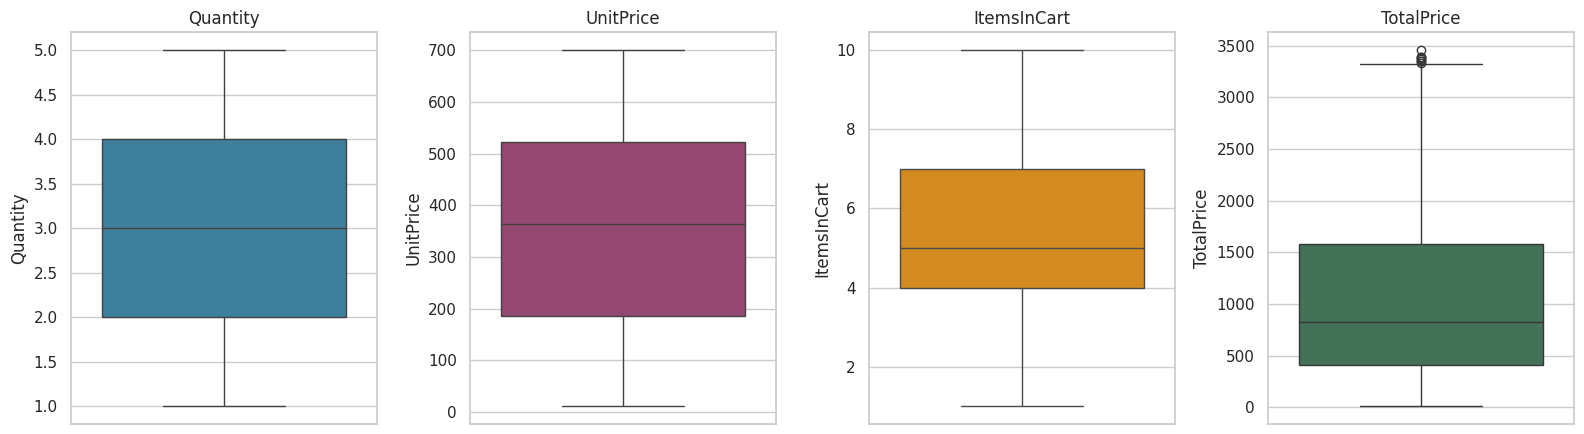

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col, color in zip(axes, numeric_cols, ['#2E86AB', '#A23B72', '#F18F01', '#3B7A57']):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(col)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_outlier_boxplots.png', bbox_inches='tight')
plt.show()


**Observation:** Only `TotalPrice` shows statistical outliers (large, high-value orders) — these are **signal, not noise** (likely bulk or premium-product orders), so they are flagged for investigation rather than removed.

In [11]:
high_value_orders = df[df['TotalPrice'] > outlier_report.loc['TotalPrice', 'upper_bound']].sort_values('TotalPrice', ascending=False)
print(f"High-value outlier orders: {len(high_value_orders)}")
high_value_orders[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice', 'PaymentMethod']]


High-value outlier orders: 8


,OrderID,Product,Quantity,UnitPrice,TotalPrice,PaymentMethod
789,ORD200789,Tablet,5,691.28,3456.40,Online
1122,ORD201122,Monitor,5,678.19,3390.95,Online
632,ORD200632,Laptop,5,678.16,3390.80,Gift Card
469,ORD200469,Chair,5,676.98,3384.90,Cash
328,ORD200328,Tablet,5,674.04,3370.20,Online
107,ORD200107,Printer,5,670.75,3353.75,Gift Card
326,ORD200326,Laptop,5,670.48,3352.40,Gift Card
1065,ORD201065,Printer,5,666.80,3334.00,Debit Card


## 7. Correlation Analysis
Mapping linear relationships between numeric variables using the Pearson
correlation coefficient.


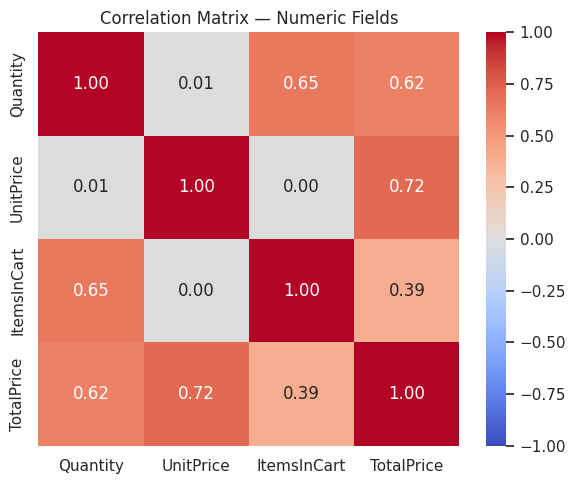

In [12]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Numeric Fields')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Observation:** `TotalPrice` correlates strongly with both `UnitPrice`
(r ≈ 0.72) and `Quantity` (r ≈ 0.62) — expected, since it is derived from
them. `ItemsInCart` correlates moderately with `Quantity` (r ≈ 0.65) but
only weakly with final `TotalPrice` (r ≈ 0.39), suggesting cart size alone
is a weak predictor of final order value — a reminder that **correlation is
a clue, not a verdict**; no causal claim is made here.


## 8. Business-Level Insights (The 'So What?' Test)

In [13]:
# Insight 1: Revenue and order performance by product
product_perf = df.groupby('Product').agg(
    total_revenue=('TotalPrice', 'sum'),
    avg_order_value=('TotalPrice', 'mean'),
    order_count=('OrderID', 'count')
).sort_values('total_revenue', ascending=False).round(2)
product_perf


,total_revenue,avg_order_value,order_count
Product,,,
Chair,195620.11,1098.99,178
Printer,195612.61,1080.73,181
Laptop,192126.56,1110.56,173
Tablet,186568.95,1042.28,179
Monitor,175651.41,1077.62,163
Desk,167459.93,985.06,170
Phone,151722.39,972.58,156


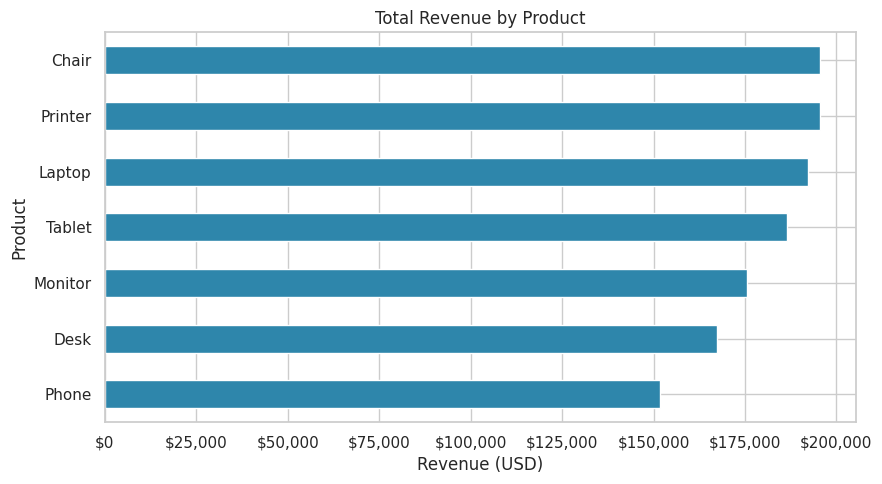

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
product_perf['total_revenue'].sort_values().plot(kind='barh', color='#2E86AB', ax=ax)
ax.set_title('Total Revenue by Product')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_revenue_by_product.png', bbox_inches='tight')
plt.show()


In [15]:
# Insight 2: Order fulfillment risk (Cancelled + Returned)
risk_statuses = ['Cancelled', 'Returned']
at_risk = df[df['OrderStatus'].isin(risk_statuses)]

risk_pct = len(at_risk) / len(df) * 100
lost_revenue = at_risk['TotalPrice'].sum()

print(f"Cancelled + Returned orders: {len(at_risk)} of {len(df)} ({risk_pct:.1f}%)")
print(f"Revenue tied up in Cancelled/Returned orders: ${lost_revenue:,.2f}")
print(f"That is {lost_revenue / df['TotalPrice'].sum() * 100:.1f}% of total recorded order value.")


Cancelled + Returned orders: 497 of 1200 (41.4%)
Revenue tied up in Cancelled/Returned orders: $519,673.91
That is 41.1% of total recorded order value.


In [16]:
# Insight 3: Average order value by payment method
payment_aov = df.groupby('PaymentMethod')['TotalPrice'].mean().sort_values(ascending=False).round(2)
payment_aov


PaymentMethod
Credit Card    1127.55
Gift Card      1070.97
Cash           1056.04
Online         1017.22
Debit Card     1001.56
Name: TotalPrice, dtype: float64

In [17]:
# Insight 4: Revenue contribution by referral / marketing channel
channel_perf = df.groupby('ReferralSource').agg(
    total_revenue=('TotalPrice', 'sum'),
    order_count=('OrderID', 'count'),
    avg_order_value=('TotalPrice', 'mean')
).sort_values('total_revenue', ascending=False).round(2)
channel_perf


,total_revenue,order_count,avg_order_value
ReferralSource,,,
Instagram,275285.45,259,1062.88
Email,261808.55,250,1047.23
Google,250441.48,241,1039.18
Facebook,250410.90,228,1098.29
Referral,226815.58,222,1021.69


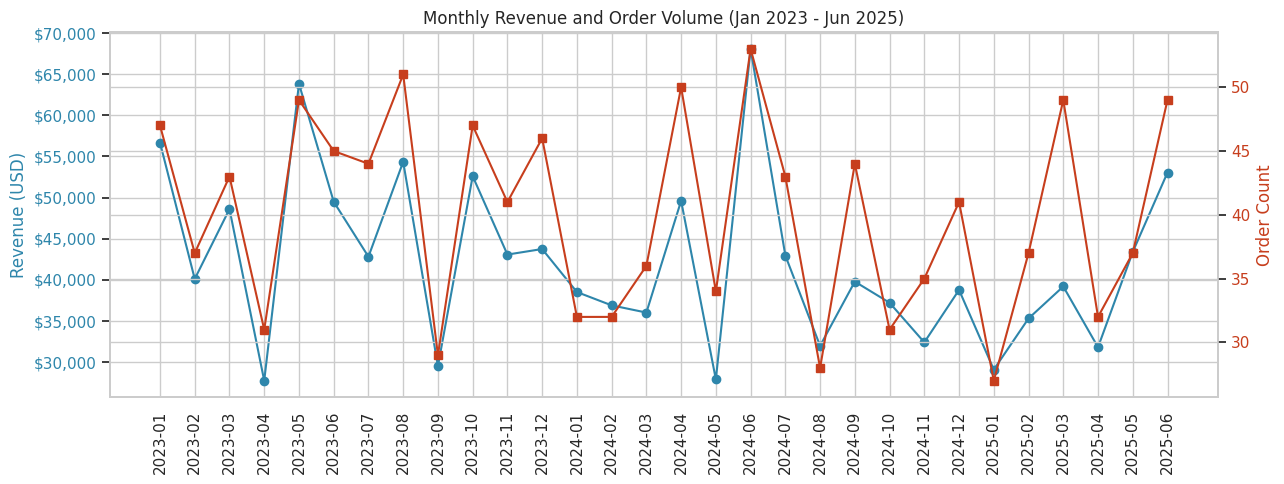

In [18]:
# Insight 5: Monthly order volume & revenue trend
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('YearMonth').agg(
    revenue=('TotalPrice', 'sum'),
    orders=('OrderID', 'count')
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly.index, monthly['revenue'], marker='o', color='#2E86AB', label='Revenue')
ax1.set_ylabel('Revenue (USD)', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_xticks(range(len(monthly.index)))
ax1.set_xticklabels(monthly.index, rotation=90)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['orders'], marker='s', color='#C73E1D', label='Order Count')
ax2.set_ylabel('Order Count', color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

ax1.set_title('Monthly Revenue and Order Volume (Jan 2023 - Jun 2025)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_monthly_trend.png', bbox_inches='tight')
plt.show()


**Observation:** Order volume and revenue fluctuate month-to-month without a strong seasonal pattern in this sample — no single month dominates, so marketing/inventory planning should not assume a fixed seasonal peak from this data alone.

## 9. Executive Summary

| # | What the Data Says | The Business Diagnosis |
|---|---|---|
| 1 | `TotalPrice` is right-skewed (mean > median) with a handful of high-value outlier orders | Use the **median**, not the mean, when reporting a "typical" order value to leadership — the mean is inflated by a small number of bulk/high-ticket orders |
| 2 | Cancelled + Returned orders make up **~41.4%** of all orders, tying up **~$519,674** in order value | This is a **fulfillment/quality risk**, not a rounding error — worth a dedicated root-cause investigation (product quality, delivery delays, payment friction) before scaling marketing spend |
| 3 | Chair, Printer, and Laptop are the top 3 products by total revenue | Prioritize inventory and supplier reliability for these three lines — they anchor the top of the revenue mix |
| 4 | Credit Card orders have the highest average order value; Debit Card the lowest | Consider whether checkout friction or credit limits are suppressing basket size on lower-AOV payment methods |
| 5 | Instagram and Email are the top two revenue-generating referral sources | These channels deserve first priority in the next marketing budget allocation review |
| 6 | `ItemsInCart` is only weakly correlated with final `TotalPrice` (r ≈ 0.39) | Cart size is not a reliable proxy for order value — avoid using it alone to forecast revenue |

*(Exact figures are computed live in Section 8 — see the executed cell output there.)*

## 10. Conclusion

This EDA pass moved the dataset from a static 1,200-row table to a set of
**quantified, decision-ready findings**. The most actionable signal is the
elevated Cancelled/Returned rate — a candidate root-cause investigation for
Project 3 (or a dedicated operations deep-dive). All supporting visuals are
saved to [`visuals/`](../visuals/) and the narrative findings are summarized
in [`reports/eda_insights_summary.md`](../reports/eda_insights_summary.md).

---
**DecodeLabs | Data Analytics Internship — Project 2 of the Industrial Training Kit**
